# Gate Family Quick Start

Let us create one pulse family that implements controlled-phase gates,

$$
\mathrm{CP}(\theta)=\operatorname{diag}(1,1,1,e^{i\theta}),
$$

for several target phases $\theta$. We use `PulseFamilyAnsatz` so the pulse duration and ansatz parameters are smooth functions of the CP phase.

In [1]:
# %pip install -q --progress-bar off rydopt # Uncomment for installation on Colab

import numpy as np
import rydopt as ro
import jax
import matplotlib.pyplot as plt

First, we choose target phases between $0.1\pi$ and $\pi$ that should be realized by the same family of pulses. Each phase defines one `TwoQubitGate`. We leave the single-qubit phase `phi` unspecified, so RydOpt may absorb any accompanying local $Z$ phase. The `GateFamily` combines their infidelities during optimization using a softmax reduction, which is controlled by the `reduction` parameter that sets the scale of per-gate infidelity differences that the optimizer should care about. We choose a value that is one order of magnitude smaller than the target infidelity that we will set later for the optimization.

In [2]:
target_phases = np.logspace(-2, 0, 8) * np.pi

sampled_gates = [
    ro.gates.TwoQubitGate(
        phi=None,
        theta=phase,
        Vnn=float("inf"),
        decay=0.0,
    )
    for phase in target_phases
]

gate_family = ro.gates.GateFamily(
    fixed_argument_gates=sampled_gates,
    argument_values=target_phases,
    reduction="softmax",
    softmax_scale=1e-4,
)

Then we choose a pulse family ansatz. The underlying pulse has constant detuning and a sine-CRAB laser-phase sweep with two coefficients. By default, the `PolynomialPulseMapWithCustomDuration` uses an empirical expression with three parameters for interpolating the duration as a function of the target phase. The detuning, laser-phase coefficients, and Rabi frequency amplitude are polynomial functions of the target phase. The degrees `0, 2, 0` of the polynomials keep the detuning phase-independent and make each laser-phase coefficient quadratic. The Rabi frequency amplitude remains fixed at one.

In [3]:
degrees = [3, 0, 2, 0]  # duration, detuning, laser phase, Rabi amplitude

pulse_map = ro.pulses.PolynomialPulseMapWithCustomDuration(degrees=degrees)
pulse_family = ro.pulses.PulseFamilyAnsatz(
    detuning_ansatz=ro.pulses.Const(),
    phase_ansatz=ro.pulses.SinCrab(2),
    pulse_map=pulse_map,
)

For multi-start optimization, we provide lower and upper bounds for random pulse-family parameters rather than a single initial guess. The bounds follow the map shapes: three Padé duration parameters, one constant detuning coefficient, two quadratic laser-phase coefficients, and no trainable Rabi parameters.

In [12]:
min_initial_params = ro.pulses.PulseFamilyParams(
    [7, 16, 0.2], [[-0.1]], [[-5.0, -5.0, -5.0], [-5.0, -5.0, -5.0]], [[]]
)
max_initial_params = ro.pulses.PulseFamilyParams(
    [8, 17, 0.3], [[0.0]], [[5.0, 5.0, 5.0], [5.0, 5.0, 5.0]], [[]]
)

Now, we optimize the pulse-family parameters with `multi_start_optimize`. The optimizer samples random initial parameter sets within the bounds, runs each candidate for up to 1000 steps, and minimizes the mean infidelity over the training CP gates. To keep the runtime reasonable for this quick-start example, we set a target fidelity of $10^{-3}$. Higher fidelities can be achieved by using a pulse family ansatz with more parameters and increasing the number of optimization steps and initializations.

In [13]:
opt_result_gate_family = ro.optimization.multi_start_optimize(
    gate_family,
    pulse_family,
    min_initial_params,
    max_initial_params,
    tol=1e-3,
    num_initializations=80,
    num_steps=1000,
    num_processes=4,
    return_history=False,
)
optimized_family_params = opt_result_gate_family.params

Started optimization using 4 processes



proc00:   0%|          | 0/1000 [00:00<?, ?it/s]

proc03:   0%|          | 0/1000 [00:00<?, ?it/s]

proc01:   0%|          | 0/1000 [00:00<?, ?it/s]

proc02:   0%|          | 0/1000 [00:00<?, ?it/s]


=== Optimization finished using multi-start Adam ===

Runtime: 267.017 seconds
Gates with infidelity below tol=1.0e-03: 1

Best gate:
> infidelity <= tol
PulseFamilyParams(
  duration_params = [ 7.67267063, 16.63672608,  0.30388681],
  detuning_params = [-0.12388568],
  phase_params =    [[ 0.04504072, -1.77715841,  4.02255891],
                     [-2.55233694,  3.22210158,  0.18531057]],
  rabi_params =     []
)


Finally, we inspect generated pulses on a fine phase grid. `generate_pulse_params` evaluates the polynomial map to obtain the single-pulse parameters corresponding to a target phase. Evaluating phases beyond the training points checks how well the optimized family interpolates.

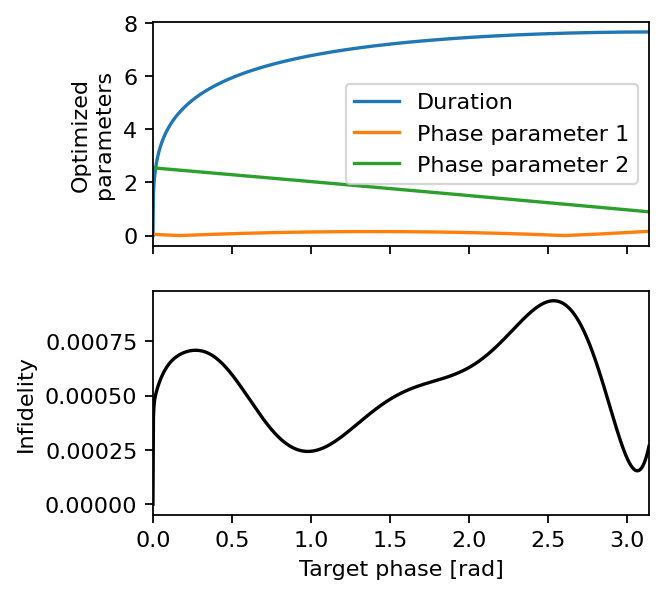

In [ ]:
phases = np.linspace(0, 1, 1000) * np.pi
durations = []
parameters = []
infidelities = []


@jax.jit
def analyze_phase(
    phase: float, family_params: ro.pulses.PulseFamilyParams
) -> tuple[jax.Array, jax.Array, jax.Array]:
    pulse = pulse_family.pulse_ansatz
    params = pulse_family.generate_pulse_params(family_params, phase)
    gate = ro.gates.TwoQubitGate(
        phi=None,
        theta=phase,
        Vnn=float("inf"),
        decay=0,
    )
    infidelity = 1 - ro.simulation.process_fidelity(gate, pulse, params)
    return params.duration[0], params.phase_params, infidelity


for phase in phases:
    duration, phase_params, infidelity = analyze_phase(phase, optimized_family_params)
    durations.append(float(duration))
    parameters.append(np.asarray(phase_params))
    infidelities.append(float(infidelity))

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(4, 4), dpi=160)
ax1.plot(phases, durations, label="Duration")
ax1.plot(phases, np.abs(parameters), label=[f"Phase parameter {i + 1}" for i in range(2)])
ax1.set_ylabel("Optimized\nparameters")
ax1.legend(loc="center right")
ax2.plot(phases, infidelities, "k-")
ax2.set_xlim(phases[0], phases[-1])
ax2.set_ylabel("Infidelity")
ax2.set_xlabel("Target phase [rad]");

We can also plot the optimized phase sweeps for the target phases in `gate_family`. The detuning and Rabi functions are hidden because they are fixed or phase-independent in this ansatz.

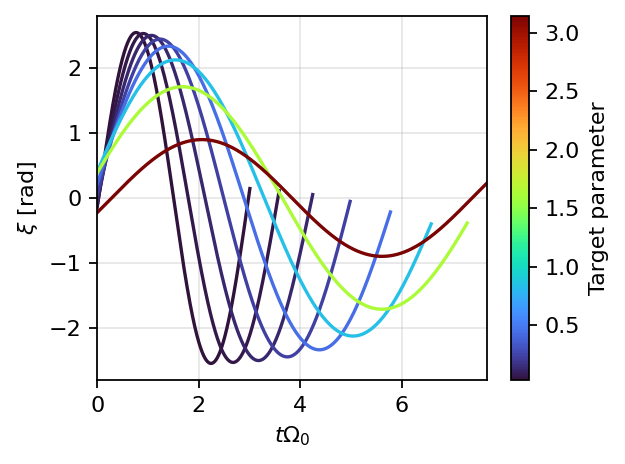

In [15]:
ro.characterization.plot_pulse_family(
    pulse_family,
    optimized_family_params,
    gate_family,
    plot_detuning=False,
    plot_rabi=False,
);